In [1]:
# 0. Common imports and settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy.stats import norm, skew, probplot
from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
# Read file and view basic overview of data
file_path = "D:/UCFFL25/STA4173/archive/nba_2022-23_all_stats_with_salary.csv"
df = pd.read_csv(file_path)
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').transpose())

Shape: (467, 52)


,Unnamed: 0,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Total Minutes,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,0.493,4.9,11.4,0.427,5.1,8.8,0.579,0.614,4.6,5.0,0.915,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,1941,24.1,0.656,0.564,0.248,2.3,16.8,9.7,30.0,1.3,0.9,12.5,31.0,5.8,2.0,7.8,0.192,7.5,0.1,7.5,4.7
1,1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,0.408,1.0,3.2,0.303,3.1,6.7,0.459,0.457,2.3,3.3,0.681,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,755,13.6,0.498,0.322,0.334,2.1,11.4,6.8,35.3,1.8,1.4,17.1,27.0,-0.4,0.7,0.3,0.020,-0.8,-0.4,-1.2,0.1
2,2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,0.436,1.2,3.9,0.311,4.7,9.7,0.487,0.481,2.8,4.3,0.656,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,2126,16.1,0.513,0.289,0.317,4.7,16.5,10.8,38.6,1.7,1.3,18.4,27.7,-0.6,2.6,1.9,0.044,0.3,-0.1,0.2,1.2
3,3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,0.500,2.2,6.9,0.321,8.9,15.3,0.580,0.549,4.6,5.9,0.768,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,1954,23.9,0.583,0.309,0.268,3.7,20.8,12.5,33.5,1.2,1.4,11.6,33.3,3.2,2.4,5.6,0.138,5.5,0.6,6.1,4.0
4,4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,0.560,2.0,4.9,0.404,8.3,13.4,0.617,0.614,6.5,7.1,0.919,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,1672,25.9,0.677,0.267,0.387,1.2,19.5,10.5,24.5,1.0,3.4,13.4,30.7,4.7,2.1,6.8,0.194,6.0,1.2,7.1,3.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467 entries, 0 to 466
Data columns (total 52 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     467 non-null    int64  
 1   Player Name    467 non-null    object 
 2   Salary         467 non-null    int64  
 3   Position       467 non-null    object 
 4   Age            467 non-null    int64  
 5   Team           467 non-null    object 
 6   GP             467 non-null    int64  
 7   GS             467 non-null    int64  
 8   MP             467 non-null    float64
 9   FG             467 non-null    float64
 10  FGA            467 non-null    float64
 11  FG%            466 non-null    float64
 12  3P             467 non-null    float64
 13  3PA            467 non-null    float64
 14  3P%            454 non-null    float64
 15  2P             467 non-null    float64
 16  2PA            467 non-null    float64
 17  2P%            463 non-null    float64
 18  eFG%      

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,467.0,NaN,NaN,NaN,233.0,134.955548,0.0,116.5,233.0,349.5,466.0
Player Name,467,467,Jacob Gilyard,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,467.0,NaN,NaN,NaN,8416598.747323,10708118.04652,5849.0,1782621.0,3722040.0,10633543.5,48070014.0
Position,467,9,SG,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,467.0,NaN,NaN,NaN,25.820128,4.275113,19.0,23.0,25.0,29.0,42.0
Team,467,75,SAC,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GP,467.0,NaN,NaN,NaN,48.233405,24.80774,1.0,31.0,55.0,68.5,83.0
GS,467.0,NaN,NaN,NaN,22.650964,27.094577,0.0,1.0,8.0,45.5,83.0
MP,467.0,NaN,NaN,NaN,19.871306,9.548684,1.8,12.5,19.2,28.3,41.0
FG,467.0,NaN,NaN,NaN,3.351392,2.457836,0.0,1.6,2.7,4.3,11.2


In [3]:
# rennme 'Unnamed: 0' column to 'ID'
df = df.rename(columns={"Unnamed: 0": "Id"})

# Remove spaces from column names
df.columns = [col.replace(" ", "") for col in df.columns]

In [4]:
#Handling Missing Data
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.concat([missing, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
display(missing_summary[missing_summary['missing_count'] > 0])

,missing_count,missing_pct
FT%,23,4.93
3P%,13,2.78
2P%,4,0.86
eFG%,1,0.21
3PAr,1,0.21
FTr,1,0.21
TS%,1,0.21
FG%,1,0.21


In [5]:
# fill in the missing data with 0s since if the data is missing, that player didn't achieve said stat
cols_to_fill_zero = [
    "FT%",
    "3P%",
    "2P%",
    "TS%",
    "3PAr",
    "FTr",
    "eFG%",
    "FG%",
]

for col in cols_to_fill_zero:
    df[col] = df[col].fillna(0)

In [6]:
#Due to players recieving the same salary whether or not they suffer a season ending injury at the beginning
#of the season, I decided to drop those who played less than 20 games
df = df[df['GP'] >= 20]

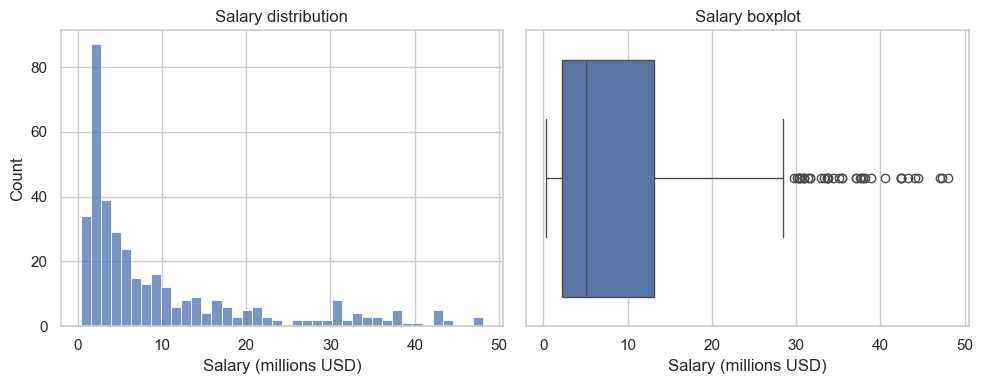

Salary summary (USD):


count    3.760000e+02
mean     9.990403e+06
std      1.114936e+07
min      3.860550e+05
25%      2.242883e+06
50%      5.092736e+06
75%      1.308500e+07
max      4.807001e+07
Name: Salary, dtype: float64

In [7]:
#View the distribution of our target variable
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Salary'].dropna()/1e6, bins=40)
plt.xlabel('Salary (millions USD)')
plt.title('Salary distribution')

plt.subplot(1,2,2)
sns.boxplot(x=df['Salary'].dropna()/1e6)
plt.xlabel('Salary (millions USD)')
plt.title('Salary boxplot')
plt.tight_layout()
plt.show()

print("Salary summary (USD):")
display(df['Salary'].describe())

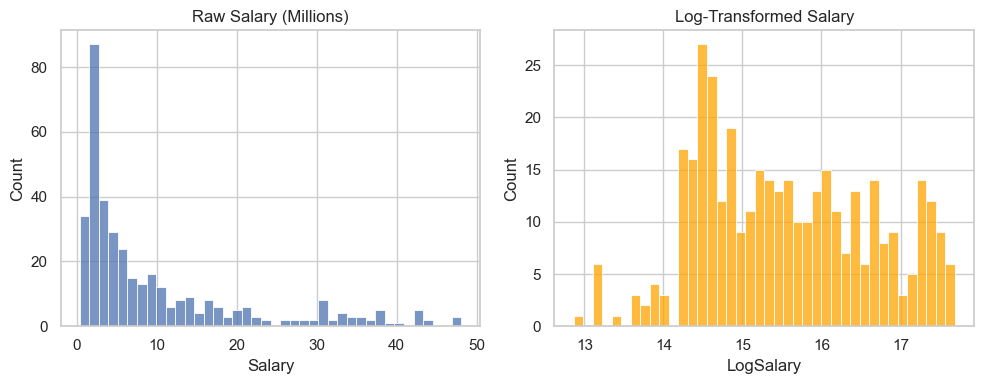

Skew (Salary): 1.6282305144785192
Skew (LogSalary): 0.15724774071550915


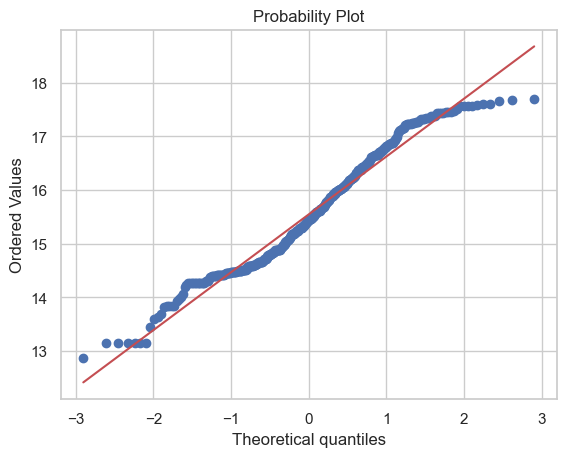

In [8]:
#Due to it being very right skewed, apply the log transformation to it as well as view qq plot
df['LogSalary'] = np.log1p(df['Salary'])
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(df['Salary']/1e6, bins=40, ax=axes[0])
axes[0].set_title('Raw Salary (Millions)')
sns.histplot(df['LogSalary'], bins=40, ax=axes[1], color='orange')
axes[1].set_title('Log-Transformed Salary')
plt.tight_layout()
plt.show()

print("Skew (Salary):", df['Salary'].skew())
print("Skew (LogSalary):", df['LogSalary'].skew())

fig = plt.figure()
res = probplot(df["LogSalary"], plot=plt)
plt.show()

LogSalary       1.000000
Salary          0.889315
MP              0.705716
FG              0.691265
PTS             0.689810
FGA             0.682263
TOV             0.643688
2PA             0.627971
2P              0.618999
GS              0.617404
TotalMinutes    0.602006
VORP            0.593305
OBPM            0.587864
FT              0.583878
FTA             0.583573
AST             0.579333
WS              0.575457
DRB             0.564469
DWS             0.559693
BPM             0.554775
STL             0.520078
USG%            0.512979
OWS             0.509534
3PA             0.492245
PER             0.488896
TRB             0.485257
3P              0.483699
PF              0.457441
AST%            0.436578
Age             0.429476
WS/48           0.313509
GP              0.296261
BLK             0.267544
FT%             0.208869
TS%             0.199758
ORB             0.196838
FTr             0.138219
eFG%            0.119835
3P%             0.108454
DRB%            0.094072


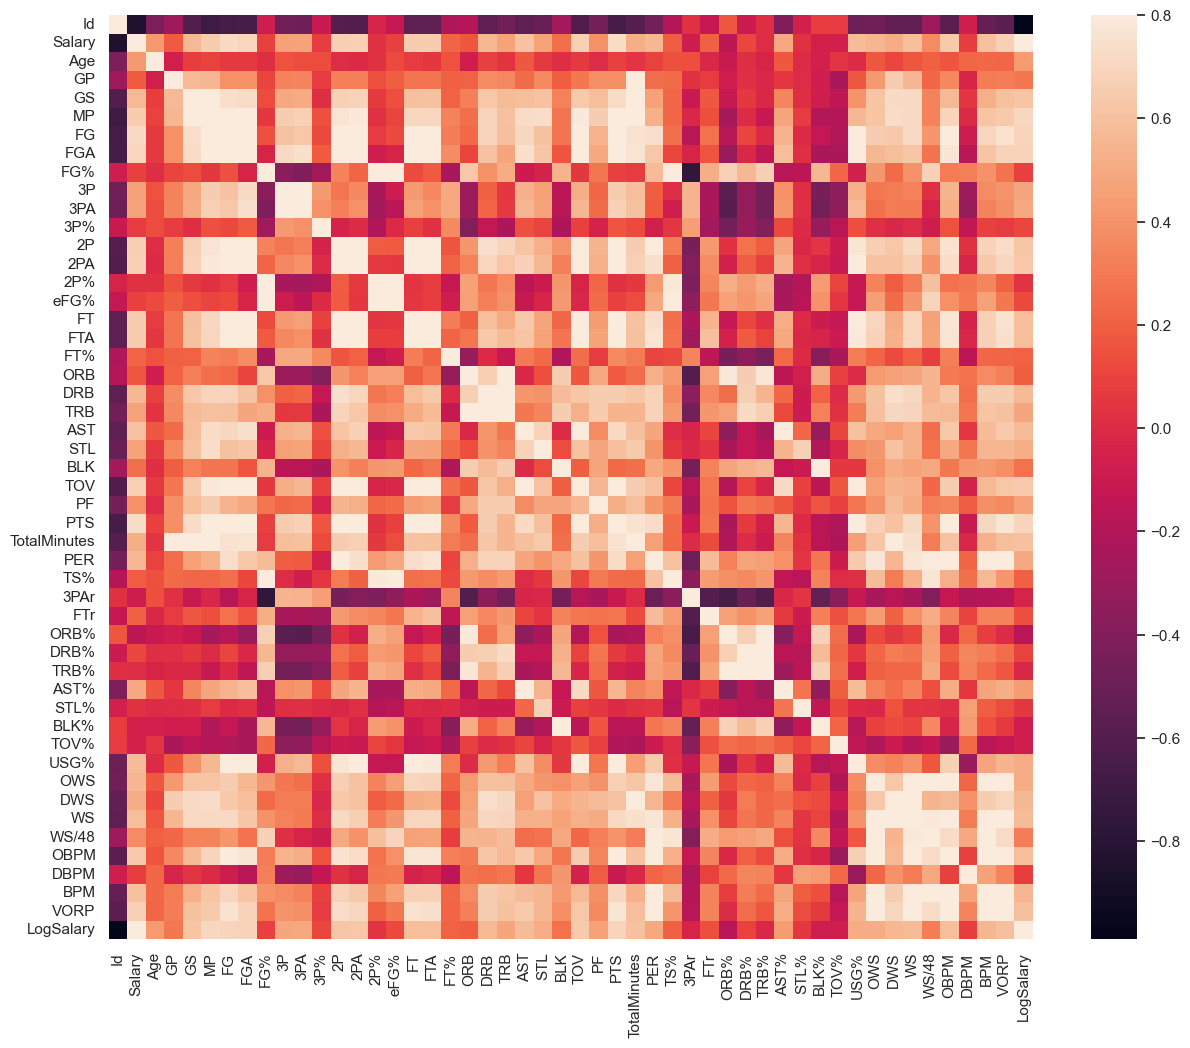

In [9]:
#Construct correlation heat map as well as view the variables with the highest correlation
numeric_df = df.select_dtypes(include=[np.number])
corrmat = numeric_df.corr()
f, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corrmat, vmax=0.8, square=True);

salary_correlations = corrmat['LogSalary']
print(salary_correlations.sort_values(ascending=False))

C:\Users\sleig\AppData\Local\Temp\ipykernel_24816\145318691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Position', y='LogSalary', data=df, palette='rainbow');


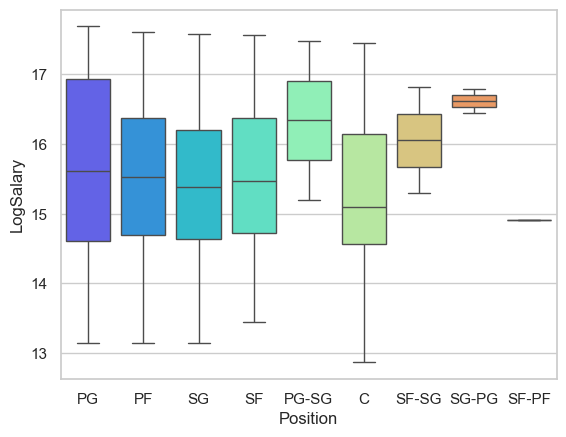

In [10]:
#View the spread of salary by position
sns.boxplot(x='Position', y='LogSalary', data=df);

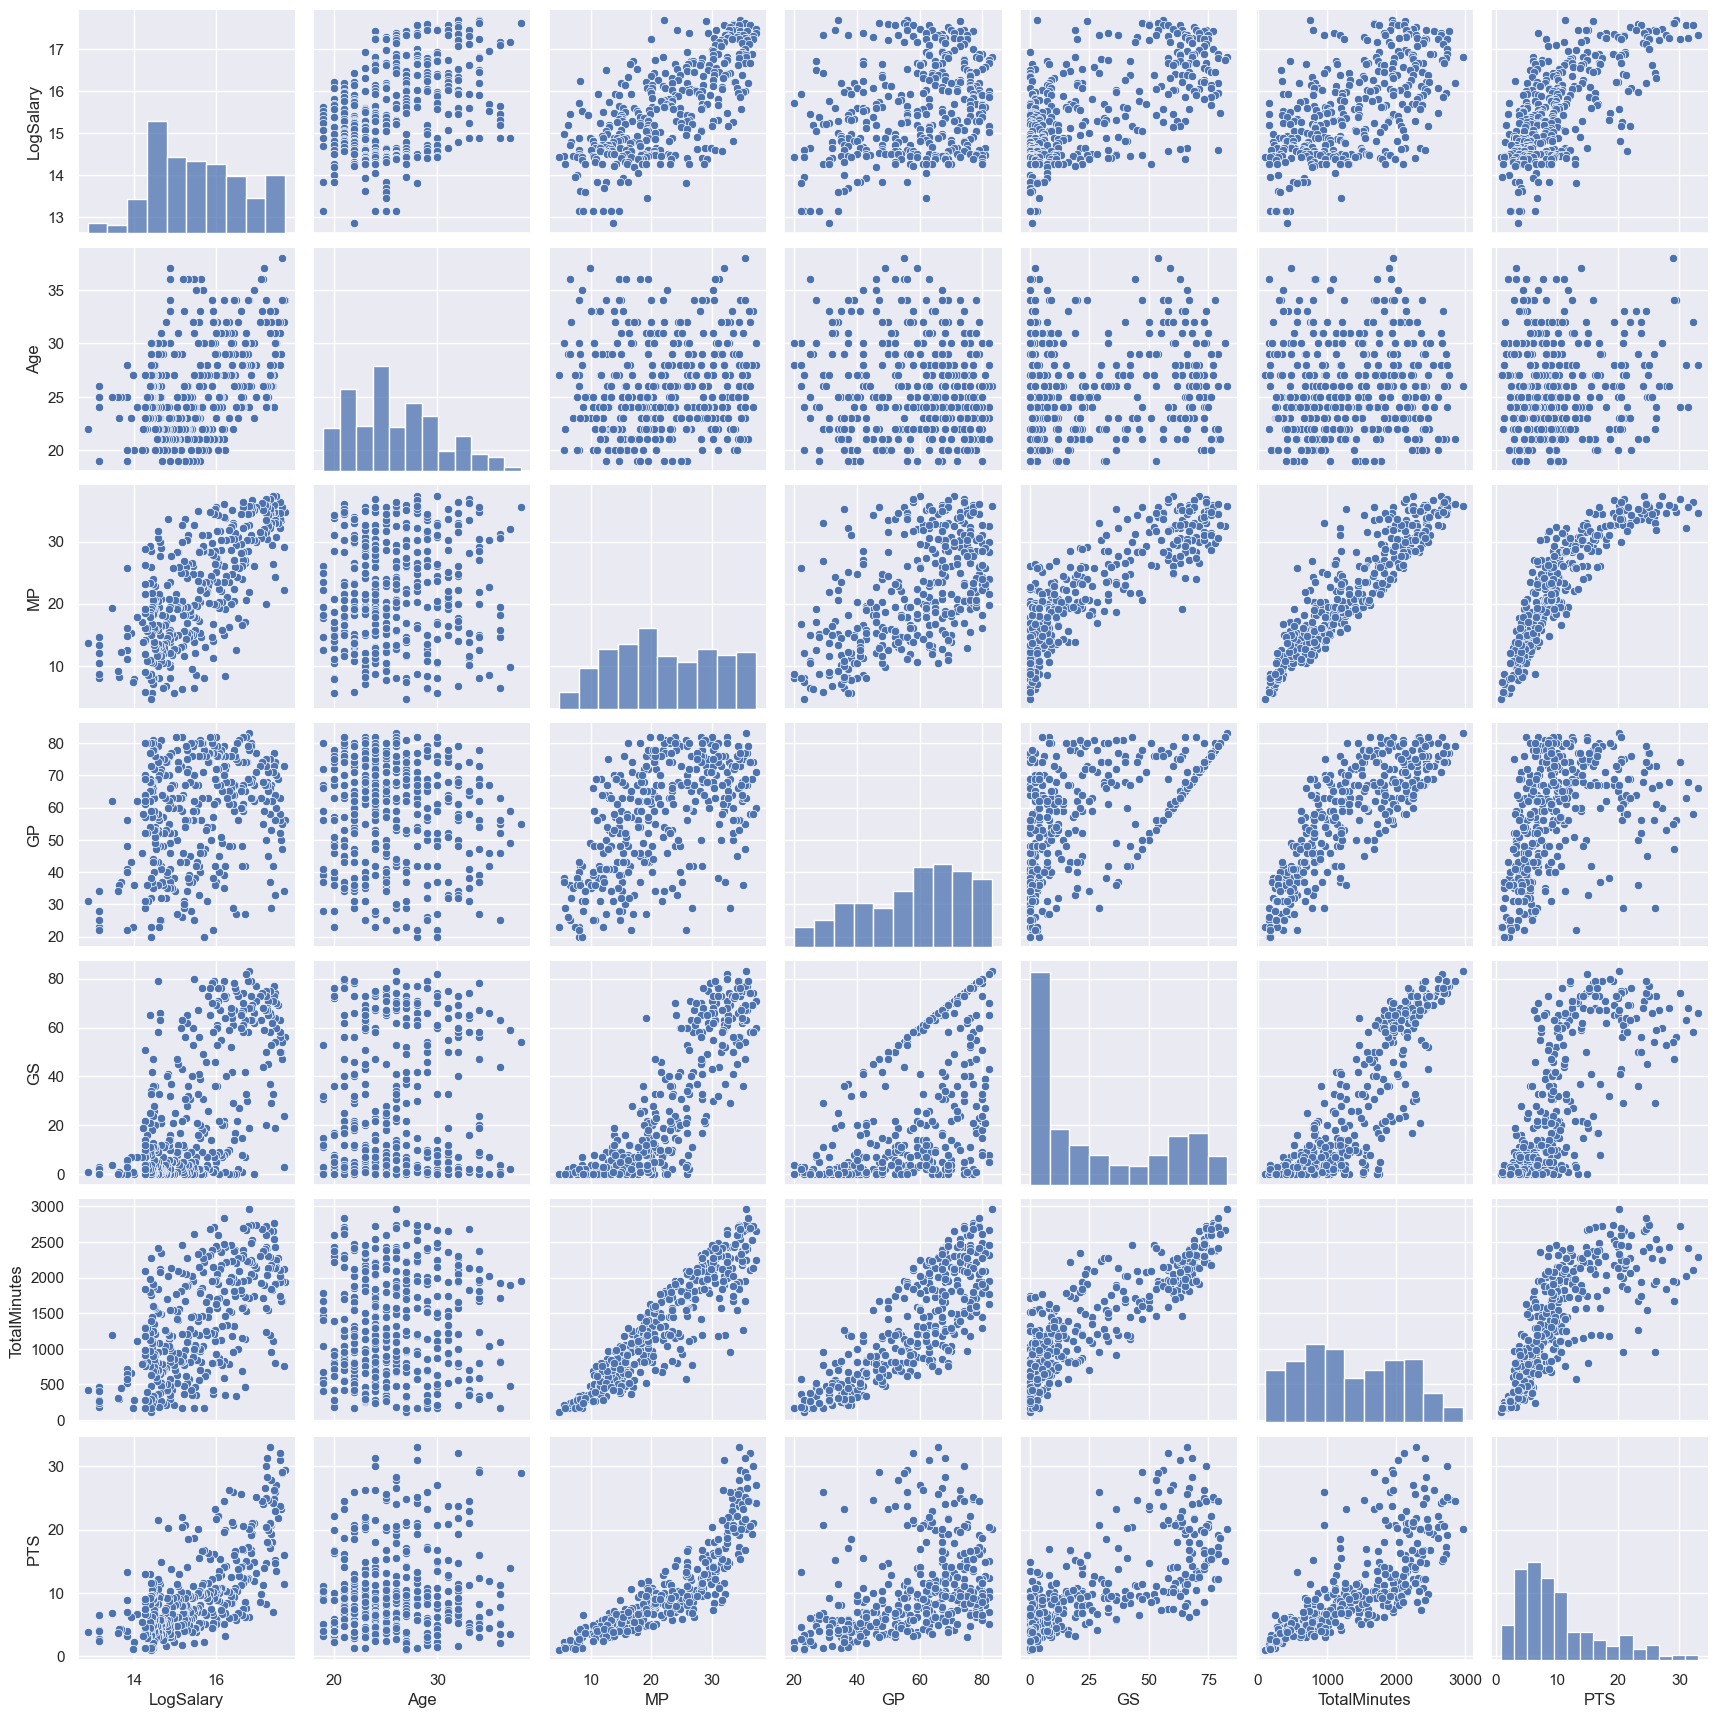

In [11]:
#Minute Stats + Games Played
sns.set()
cols = [
    "LogSalary",
    "Age",
    "MP",
    "GP",
    "GS",
    "TotalMinutes",
    "PTS"
]
sns.pairplot(df[cols], height=2.5)
plt.show();

In [12]:
exclude = ['Id','Salary','LogSalary']
numeric_columns = [col for col in numeric_df.columns if col not in exclude]

In [13]:
#To do some initial dimension reduction I decided to drop any varriable whos correlation with the target variable
# Was less than 25%

low_corr_columns = [col for col in numeric_columns if abs(corrmat.loc[col, 'Salary']) < 0.25]

print(low_corr_columns)

numeric_df.drop(columns=low_corr_columns, inplace=True)

df.drop(columns=low_corr_columns, inplace=True)

['GP', 'FG%', '3P%', '2P%', 'eFG%', 'FT%', 'ORB', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'STL%', 'BLK%', 'TOV%', 'DBPM']


In [14]:
df

,Id,PlayerName,Salary,Position,Age,Team,GS,MP,FG,FGA,3P,3PA,2P,2PA,FT,FTA,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,TotalMinutes,PER,AST%,USG%,OWS,DWS,WS,WS/48,OBPM,BPM,VORP,LogSalary
0,0,Stephen Curry,48070014,PG,34,GSW,56,34.7,10.0,20.2,4.9,11.4,5.1,8.8,4.6,5.0,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,1941,24.1,30.0,31.0,5.8,2.0,7.8,0.192,7.5,7.5,4.7,17.688169
1,1,John Wall,47345760,PG,32,LAC,3,22.2,4.1,9.9,1.0,3.2,3.1,6.7,2.3,3.3,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,755,13.6,35.3,27.0,-0.4,0.7,0.3,0.020,-0.8,-1.2,0.1,17.672988
2,2,Russell Westbrook,47080179,PG,34,LAL/LAC,24,29.1,5.9,13.6,1.2,3.9,4.7,9.7,2.8,4.3,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,2126,16.1,38.6,27.7,-0.6,2.6,1.9,0.044,0.3,0.2,1.2,17.667363
3,3,LeBron James,44474988,PF,38,LAL,54,35.5,11.1,22.2,2.2,6.9,8.9,15.3,4.6,5.9,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,1954,23.9,33.5,33.3,3.2,2.4,5.6,0.138,5.5,6.1,4.0,17.610438
4,4,Kevin Durant,44119845,PF,34,BRK/PHO,47,35.6,10.3,18.3,2.0,4.9,8.3,13.4,6.5,7.1,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,1672,25.9,24.5,30.7,4.7,2.1,6.8,0.194,6.0,7.1,3.9,17.602420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,418,Luka Garza,508891,C,24,MIN,0,8.7,2.3,4.1,0.5,1.4,1.8,2.8,1.5,1.9,1.1,2.3,0.6,0.1,0.1,0.5,1.5,6.5,243,23.0,11.8,26.9,0.9,0.2,1.1,0.211,2.2,-0.4,0.1,13.139991
419,419,Kevon Harris,508891,SG,25,ORL,0,13.4,1.4,3.1,0.5,1.3,0.9,1.9,0.9,1.2,1.2,2.1,0.5,0.5,0.1,0.6,1.6,4.1,457,9.2,4.7,13.7,0.2,0.4,0.6,0.065,-3.5,-3.6,-0.2,13.139991
422,422,Dominick Barlow,508891,PF,19,SAS,0,14.6,1.6,3.1,0.0,0.1,1.6,2.9,0.6,0.9,2.0,3.6,0.9,0.4,0.7,0.5,2.0,3.9,408,12.4,7.6,11.3,0.5,0.2,0.7,0.082,-3.7,-4.6,-0.3,13.139991
424,424,Jeff Dowtin,508891,PG,25,TOR,0,10.4,1.0,2.3,0.2,0.6,0.8,1.6,0.2,0.4,0.7,0.9,1.2,0.4,0.1,0.2,0.5,2.4,259,9.9,15.5,10.9,0.2,0.2,0.4,0.076,-2.8,-1.9,0.0,13.139991


In [15]:
#Here I encoded the position and team variable as dummy variables

from sklearn.preprocessing import LabelEncoder

# Create label encoders
position_encoder = LabelEncoder()
team_encoder = LabelEncoder()

# Perform label encoding for 'Position' and 'Team' variables
df['Position_encoded'] = position_encoder.fit_transform(df['Position'])
df['Team_encoded'] = team_encoder.fit_transform(df['Team'])

# Drop the original 'Position' and 'Team' columns
df.drop(['Position', 'Team'], axis=1, inplace=True)
df.head()

,Id,PlayerName,Salary,Age,GS,MP,FG,FGA,3P,3PA,2P,2PA,FT,FTA,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,TotalMinutes,PER,AST%,USG%,OWS,DWS,WS,WS/48,OBPM,BPM,VORP,LogSalary,Position_encoded,Team_encoded
0,0,Stephen Curry,48070014,34,56,34.7,10.0,20.2,4.9,11.4,5.1,8.8,4.6,5.0,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,1941,24.1,30.0,31.0,5.8,2.0,7.8,0.192,7.5,7.5,4.7,17.688169,2,22
1,1,John Wall,47345760,32,3,22.2,4.1,9.9,1.0,3.2,3.1,6.7,2.3,3.3,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,755,13.6,35.3,27.0,-0.4,0.7,0.3,0.020,-0.8,-1.2,0.1,17.672988,2,29
2,2,Russell Westbrook,47080179,34,24,29.1,5.9,13.6,1.2,3.9,4.7,9.7,2.8,4.3,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,2126,16.1,38.6,27.7,-0.6,2.6,1.9,0.044,0.3,0.2,1.2,17.667363,2,34
3,3,LeBron James,44474988,38,54,35.5,11.1,22.2,2.2,6.9,8.9,15.3,4.6,5.9,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,1954,23.9,33.5,33.3,3.2,2.4,5.6,0.138,5.5,6.1,4.0,17.610438,1,32
4,4,Kevin Durant,44119845,34,47,35.6,10.3,18.3,2.0,4.9,8.3,13.4,6.5,7.1,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,1672,25.9,24.5,30.7,4.7,2.1,6.8,0.194,6.0,7.1,3.9,17.602420,1,6


In [16]:
#From here on out is focused on regression
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

In [20]:
lr_w_int = LinearRegression()
lr_no_int = LinearRegression(fit_intercept=False)
elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.1)
rf = RandomForestRegressor(n_estimators=500)
dt = DecisionTreeRegressor(max_depth=10)

In [17]:
def k_fold_regression(
    data,
    regressor,
    target_column="Salary",
    cols_to_ignore=['Salary', 'Id', 'PlayerName', 'LogSalary'],
    n_splits=5,
    tune_hyperparameters=False,
    model_name=None
):
    rmse_scores = []
    train_sizes = []
    test_sizes = []
    fold_results = []

    # Prepare the feature matrix X and target vector y
    X = data.drop(columns=cols_to_ignore)
    y = data[target_column]

    # Initialize KFold cross-validator
    kf = KFold(n_splits=n_splits, shuffle=True)

    # Cross-validation process
    foldCount = 0
    fold_models = []
    for train_index, val_index in kf.split(X):
        # Split into training and validation folds
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

        # Fit the model on the training fold
        regressor.fit(X_train_fold, np.log1p(y_train_fold))  # Fit on log-transformed target
        fold_models.append(regressor)
        y_pred_log_fold = regressor.predict(X_val_fold)
        y_pred_fold = np.expm1(y_pred_log_fold)  # Convert back to original scale

        # Calculate RMSE for the validation fold
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))

        # if regular xgboost, then print rmse for best folds since this is a high performing model
        if isinstance(regressor, RandomForestRegressor):
            print(f"Random Forest: {rmse:.4f}, Train Size: {len(y_train_fold)}, Test Size: {len(y_val_fold)}")

        rmse_scores.append(rmse)
        train_sizes.append(len(y_train_fold))
        test_sizes.append(len(y_val_fold))

        # Record results for 'Id', 'Actual', 'Predicted', 'Fold', and 'Set' in a list
        fold_results.append({
            'Id' : foldCount,
            'Actual': y_val_fold.tolist(),
            'Predicted': y_pred_fold,
            'rmse' : rmse
        })
        foldCount += 1

        
    # Create a DataFrame from the results
    result_df = pd.DataFrame(
        fold_results, columns=["Id", "Actual", "Predicted", 'rmse']
    )

    return result_df, rmse_scores, train_sizes, test_sizes, fold_models

In [18]:
def compute_rmse_std_k_fold(df, model, tune_hyper=False, model_name=None):
    rmse_list = []
        
    rmse_list.append(k_fold_regression(df, model, tune_hyperparameters=tune_hyper, model_name=model_name)[1])

    mean = np.mean(rmse_list)
    std = np.std(rmse_list)

    return mean, std

In [21]:
#Get the avg rmse and std over 30 tests for each model
lr_no_int_list = compute_rmse_std_k_fold(df, lr_no_int)
lr_w_int_list = compute_rmse_std_k_fold(df, lr_w_int)
elastic_net_list = compute_rmse_std_k_fold(df, elastic_net)
dt_list = compute_rmse_std_k_fold(df, dt)
rf_list = compute_rmse_std_k_fold(df, rf)

# plot RMSE and STD for each Algorithm
data = {
    "Linear (No Intercept)": lr_no_int_list,
    "Linear (w/ Intercept)": lr_w_int_list,
    "Elastic Net": elastic_net_list,
    "Decision Tree": dt_list,
    "Random Forest": rf_list,
}
data_df = pd.DataFrame(data=data).T.reset_index().sort_values(by=[0], ascending=True)
data_df.columns = ["Algorithm", "RMSE", "STD"]

D:\ANACONDA\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.724e+00, tolerance: 3.675e-02
  model = cd_fast.enet_coordinate_descent(
D:\ANACONDA\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.542e-02, tolerance: 3.558e-02
  model = cd_fast.enet_coordinate_descent(
D:\ANACONDA\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.485e+01, tolerance: 3.579e-02
  model = cd_fast.enet_coo

Random Forest: 6229033.5663, Train Size: 300, Test Size: 76
Random Forest: 5487097.8772, Train Size: 301, Test Size: 75
Random Forest: 4817094.9190, Train Size: 301, Test Size: 75
Random Forest: 6386631.0776, Train Size: 301, Test Size: 75
Random Forest: 8198799.4583, Train Size: 301, Test Size: 75


In [22]:
data_df

,Algorithm,RMSE,STD
4,Random Forest,6.223731e+06,1.135668e+06
2,Elastic Net,6.964050e+06,2.313277e+06
1,Linear (w/ Intercept),7.319729e+06,1.335822e+06
3,Decision Tree,7.800992e+06,1.521018e+06
0,Linear (No Intercept),1.081921e+07,1.957869e+06


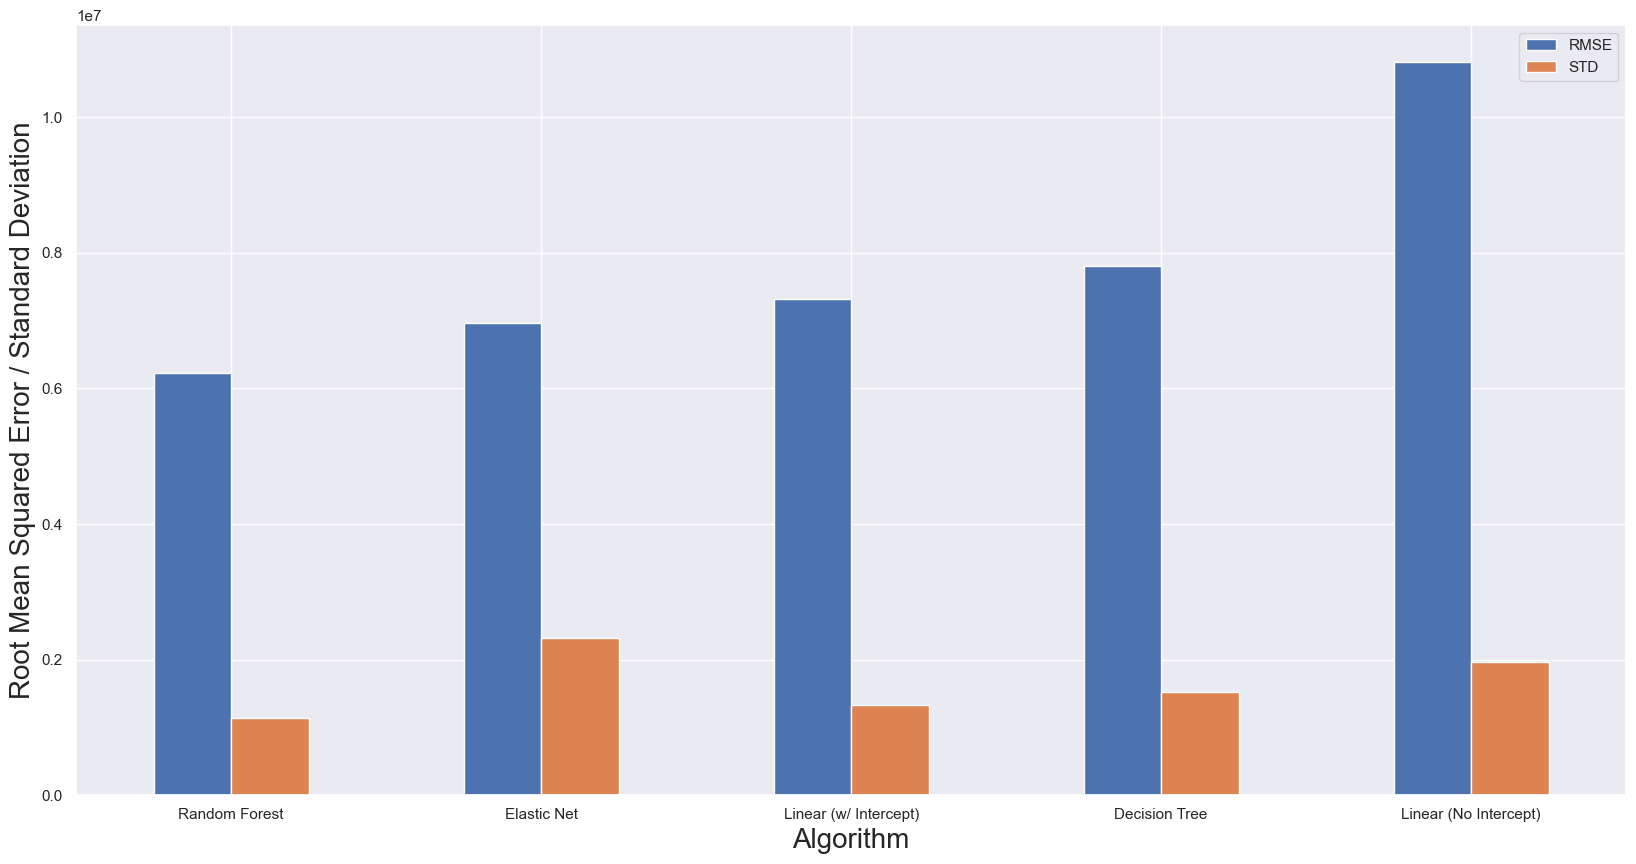

In [23]:
#Bar Plot of each models performance
data_df.plot(kind="bar", x="Algorithm", y=["RMSE", "STD"], figsize=(20, 10), rot=0)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Root Mean Squared Error / Standard Deviation", fontsize=20)
plt.show()

In [61]:
cols_to_ignore=['Salary', 'Id', 'PlayerName', 'LogSalary']
X = df.drop(columns=cols_to_ignore)

In [62]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
print(feat_importances.sort_values(ascending=False))

MP                  0.310768
Age                 0.140486
GS                  0.067221
PTS                 0.057950
VORP                0.048618
FG                  0.041041
TOV                 0.031096
3PA                 0.030854
FGA                 0.024626
TotalMinutes        0.021878
2PA                 0.018297
USG%                0.017072
Team_encoded        0.014554
AST%                0.014180
AST                 0.012970
DWS                 0.012609
PF                  0.011710
OBPM                0.011556
TRB                 0.010517
PER                 0.010241
DRB                 0.009763
WS/48               0.009720
FT                  0.009247
FTA                 0.008517
STL                 0.008406
3P                  0.008130
BPM                 0.007565
2P                  0.007334
WS                  0.007049
BLK                 0.006756
OWS                 0.005871
Position_encoded    0.003397
dtype: float64


MP                  0.519684
Age                 0.165536
AST%                0.049899
TotalMinutes        0.040265
3PA                 0.039091
DWS                 0.024668
OBPM                0.017864
BLK                 0.012488
GS                  0.011450
TOV                 0.011442
2PA                 0.011032
Team_encoded        0.010725
AST                 0.008423
WS                  0.007642
TRB                 0.007632
BPM                 0.006884
PF                  0.005862
STL                 0.005691
DRB                 0.005372
FGA                 0.005033
USG%                0.004708
OWS                 0.004672
VORP                0.003806
FT                  0.003186
3P                  0.003089
PTS                 0.003020
WS/48               0.002802
Position_encoded    0.002780
FG                  0.002325
PER                 0.001855
FTA                 0.000570
2P                  0.000502
dtype: float64


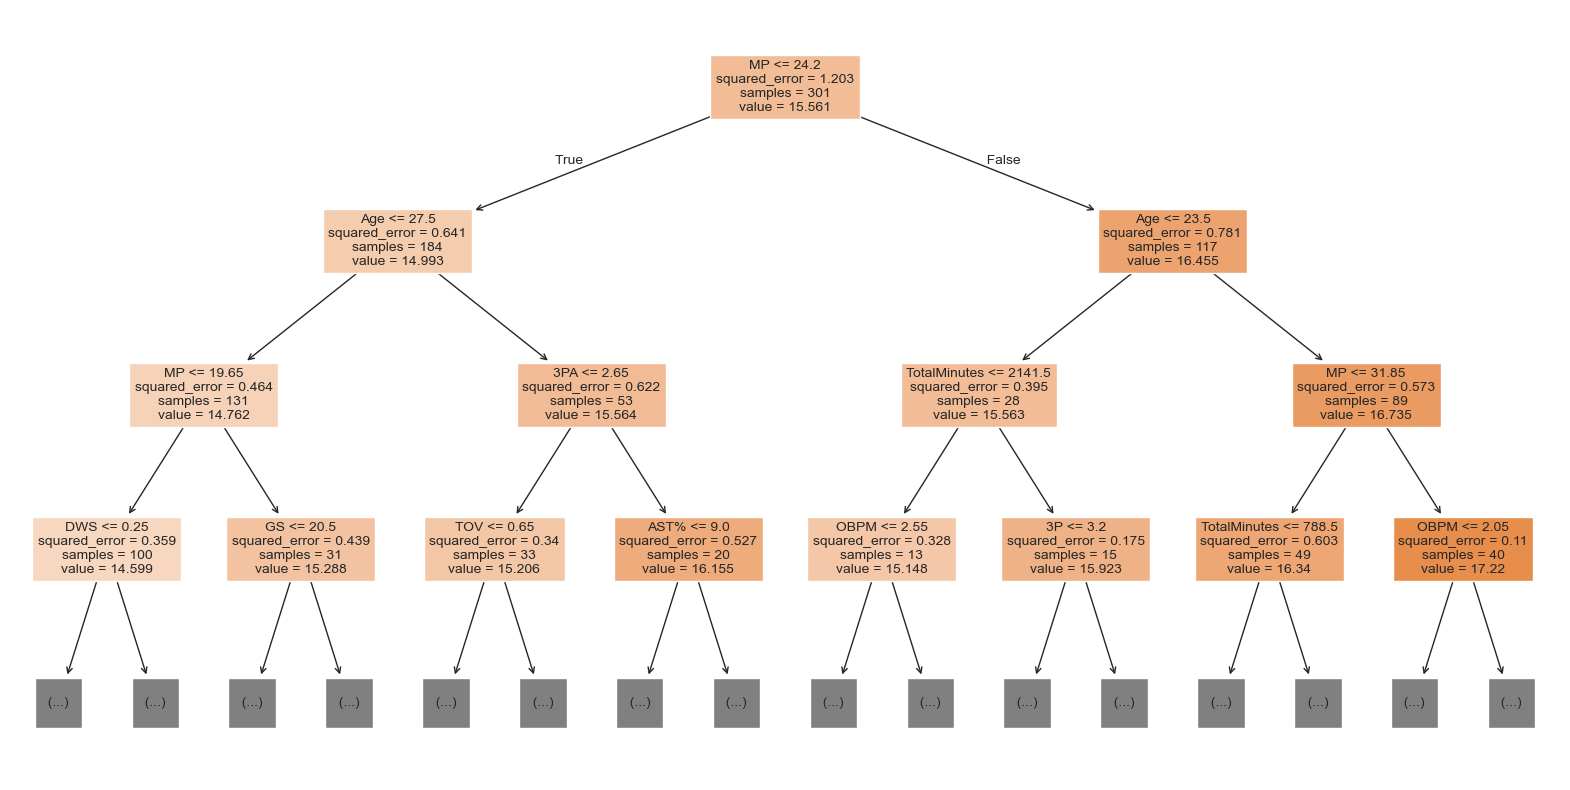

In [66]:
from sklearn import tree

feat_importances = pd.Series(dt.feature_importances_, index=X.columns)
print(feat_importances.sort_values(ascending=False))

plt.figure(figsize=(20,10))
tree.plot_tree(dt, feature_names=X.columns, filled=True, max_depth=3, fontsize=10)  # show only top 3 levels
plt.show()